# Disease Prediction with Symptoms and Lab Tests
This notebook demonstrates how to augment the `Symptom2Disease` dataset with synthetic laboratory test values, and build a multimodal machine learning model to predict diseases using both text descriptions (symptoms) and numerical data (lab tests).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')


## 1. Load Data and Augment with Synthetic Lab Features
We will create a function that generates synthetic lab tests based on the underlying disease.


In [2]:
# Load original dataset
df = pd.read_csv('Symptom2Disease.csv')
print(f"Original dataset shape: {df.shape}")
display(df.head(10))


Original dataset shape: (1200, 3)


,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,4,Psoriasis,"My nails have small dents or pits in them, and..."
5,5,Psoriasis,The skin on my palms and soles is thickened an...
6,6,Psoriasis,"The skin around my mouth, nose, and eyes is re..."
7,7,Psoriasis,My skin is very sensitive and reacts easily to...
8,8,Psoriasis,I have noticed a sudden peeling of skin at dif...
9,9,Psoriasis,The skin on my genitals is red and inflamed. I...


In [3]:
# Generate Synthetic Lab Tests
np.random.seed(42)

def generate_lab_tests(disease, n_samples):
    # Default normal ranges
    temp = np.random.normal(98.6, 0.5, n_samples) # Temperature in F
    sys_bp = np.random.normal(110, 10, n_samples) # Systolic BP
    dia_bp = np.random.normal(70, 5, n_samples)   # Diastolic BP
    wbc = np.random.normal(7000, 1500, n_samples) # WBC count
    fbs = np.random.normal(90, 10, n_samples)     # Fasting Blood Sugar
    bilirubin = np.random.normal(0.8, 0.2, n_samples) # Bilirubin Total
    
    # Disease specific modifications
    if disease in ['Typhoid', 'Chicken pox', 'Pneumonia', 'Malaria']:
        temp = np.random.normal(102.5, 1.0, n_samples) # High Fever
        wbc = np.random.normal(12000, 2000, n_samples) # Elevated WBC
    elif disease == 'Hypertension':
        sys_bp = np.random.normal(160, 15, n_samples) # High BP
        dia_bp = np.random.normal(100, 10, n_samples)
    elif disease == 'diabetes':
        fbs = np.random.normal(200, 40, n_samples) # High Blood Sugar
    elif disease == 'Jaundice':
        bilirubin = np.random.normal(5.0, 1.5, n_samples) # High Bilirubin
    elif disease == 'Dengue':
        temp = np.random.normal(102.5, 1.0, n_samples) # High Fever
        wbc = np.random.normal(3000, 800, n_samples)   # Low WBC
        
    return pd.DataFrame({
        'Temperature_F': np.round(temp, 1),
        'Systolic_BP': np.round(sys_bp),
        'Diastolic_BP': np.round(dia_bp),
        'WBC_Count': np.round(wbc),
        'Fasting_Blood_Sugar': np.round(fbs, 1),
        'Bilirubin_Total': np.round(bilirubin, 1)
    })

# Apply to entire dataframe
lab_dfs = []
for disease in df['label'].unique():
    subset = df[df['label'] == disease]
    n = len(subset)
    lab_data = generate_lab_tests(disease, n)
    lab_data.index = subset.index
    lab_dfs.append(lab_data)

# Combine
lab_df_all = pd.concat(lab_dfs).sort_index()
df_augmented = pd.concat([df, lab_df_all], axis=1)

print(f"Augmented dataset shape: {df_augmented.shape}")
display(df_augmented.head())


Augmented dataset shape: (1200, 9)


,Unnamed: 0,label,text,Temperature_F,Systolic_BP,Diastolic_BP,WBC_Count,Fasting_Blood_Sugar,Bilirubin_Total
0,0,Psoriasis,I have been experiencing a skin rash on my arm...,98.8,113.0,63.0,7376.0,93.6,0.5
1,1,Psoriasis,"My skin has been peeling, especially on my kne...",98.5,106.0,68.0,7520.0,95.6,1.0
2,2,Psoriasis,I have been experiencing joint pain in my fing...,98.9,103.0,68.0,5980.0,100.8,1.2
3,3,Psoriasis,"There is a silver like dusting on my skin, esp...",99.4,116.0,66.0,7348.0,100.5,1.0
4,4,Psoriasis,"My nails have small dents or pits in them, and...",98.5,120.0,69.0,7440.0,76.2,0.5


In [4]:
# Save the augmented dataset to CSV for future use
df_augmented.to_csv('Symptom2Disease_with_Labs.csv', index=False)
print("Saved augmented dataset to 'Symptom2Disease_with_Labs.csv'")


Saved augmented dataset to 'Symptom2Disease_with_Labs.csv'


## 2. Temporal Feature Handling
We add synthetic temporal data to simulate the time at which symptoms and lab results were recorded. This allows the model to potentially capture seasonal trends in disease occurrence.

In [5]:
# Add a synthetic report date to simulate temporal data
np.random.seed(42)
start_date = pd.to_datetime('2023-01-01')
df_augmented['Report_Date'] = start_date + pd.to_timedelta(np.random.randint(0, 365, size=len(df_augmented)), unit='D')

# Extract temporal features
df_augmented['Report_Month'] = df_augmented['Report_Date'].dt.month
df_augmented['Report_Day'] = df_augmented['Report_Date'].dt.day
df_augmented['Is_Weekend'] = (df_augmented['Report_Date'].dt.weekday >= 5).astype(int)

print("Temporal features added.")
display(df_augmented[['Report_Date', 'Report_Month', 'Report_Day', 'Is_Weekend']].head())

Temporal features added.


,Report_Date,Report_Month,Report_Day,Is_Weekend
0,2023-04-13,4,13,0
1,2023-12-15,12,15,0
2,2023-09-28,9,28,0
3,2023-04-17,4,17,0
4,2023-03-13,3,13,0


## 3. Data Validation and Correction
Ensuring data integrity by checking for missing values, removing irrelevant features, and validating clinical parameters.

In [6]:
# Fig 4.3 Checking Data Completeness
print("--- Fig 4.3 Checking Data Completeness ---")
display(df_augmented.isnull().sum())

# Fig 4.4 Removing Irrelevant Columns
print("\n--- Fig 4.4 Removing Irrelevant Columns ---")
if 'Unnamed: 0' in df_augmented.columns:
    df_augmented.drop(columns=['Unnamed: 0'], inplace=True)
    print("Dropped 'Unnamed: 0'")

# Fig 4.5 Validating Lab Values
print("\n--- Fig 4.5 Validating Lab Values ---")
ranges = {
    'Temperature_F': (90, 110),
    'Systolic_BP': (60, 250),
    'Diastolic_BP': (40, 150),
    'WBC_Count': (1000, 50000),
    'Fasting_Blood_Sugar': (40, 600),
    'Bilirubin_Total': (0, 30)
}

for col, (min_val, max_val) in ranges.items():
    invalid = df_augmented[(df_augmented[col] < min_val) | (df_augmented[col] > max_val)]
    print(f"{col}: {len(invalid)} values outside normal range ({min_val}-{max_val})")

# Fig 4.6 Correcting Abnormal Data
print("\n--- Fig 4.6 Correcting Abnormal Data ---")
invalid_bp = df_augmented[df_augmented['Systolic_BP'] <= df_augmented['Diastolic_BP']]
if len(invalid_bp) > 0:
    print(f"Found {len(invalid_bp)} cases where Systolic BP <= Diastolic BP. Correcting...")
    temp_sys = df_augmented.loc[invalid_bp.index, 'Systolic_BP'].copy()
    df_augmented.loc[invalid_bp.index, 'Systolic_BP'] = df_augmented.loc[invalid_bp.index, 'Diastolic_BP']
    df_augmented.loc[invalid_bp.index, 'Diastolic_BP'] = temp_sys
else:
    print("No abnormal blood pressure correlations found.")

--- Fig 4.3 Checking Data Completeness ---


Unnamed: 0             0
label                  0
text                   0
Temperature_F          0
Systolic_BP            0
Diastolic_BP           0
WBC_Count              0
Fasting_Blood_Sugar    0
Bilirubin_Total        0
Report_Date            0
Report_Month           0
Report_Day             0
Is_Weekend             0
dtype: int64


--- Fig 4.4 Removing Irrelevant Columns ---
Dropped 'Unnamed: 0'

--- Fig 4.5 Validating Lab Values ---
Temperature_F: 0 values outside normal range (90-110)
Systolic_BP: 0 values outside normal range (60-250)
Diastolic_BP: 0 values outside normal range (40-150)
WBC_Count: 0 values outside normal range (1000-50000)
Fasting_Blood_Sugar: 0 values outside normal range (40-600)
Bilirubin_Total: 0 values outside normal range (0-30)

--- Fig 4.6 Correcting Abnormal Data ---
Found 1 cases where Systolic BP <= Diastolic BP. Correcting...


## 4. Exploratory Data Analysis & Visualization
After preprocessing and augmentation, we perform EDA to understand the distribution of diseases and the relationship between lab values and conditions.

### 4.1 Disease Distribution
First, let's visualize the balance of our classes in the augmented dataset.

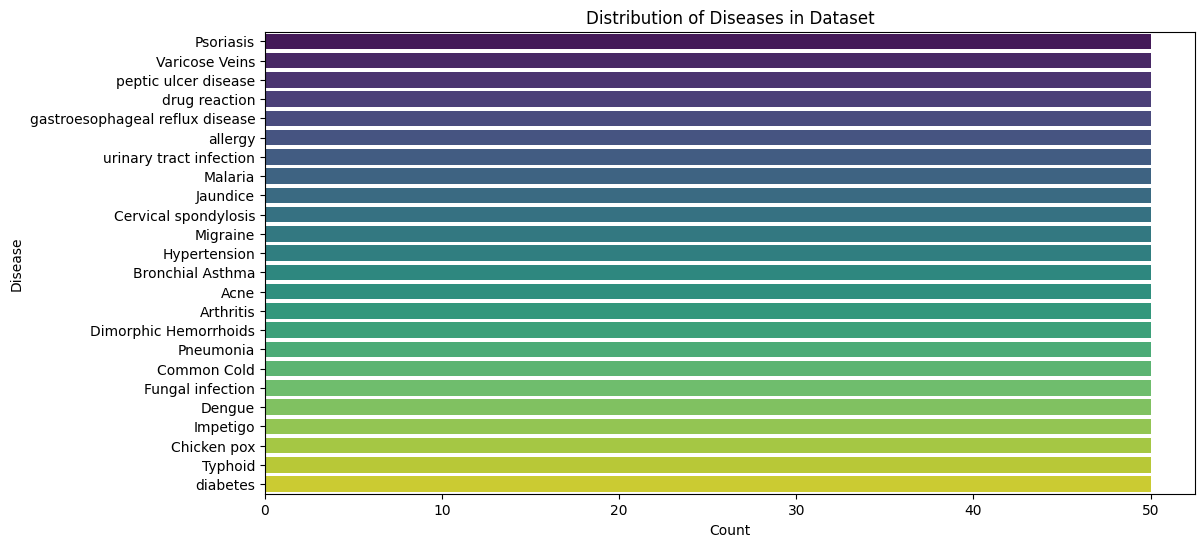

In [9]:
# Fig 4.7 Disease Distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df_augmented, y='label', order=df_augmented['label'].value_counts().index, palette='viridis')
plt.title('Distribution of Diseases in Dataset')
plt.xlabel('Count')
plt.ylabel('Disease')
plt.show()

### 4.2 Lab Value Distributions by Disease
We can analyze how different lab parameters vary across conditions to identify key diagnostic markers.

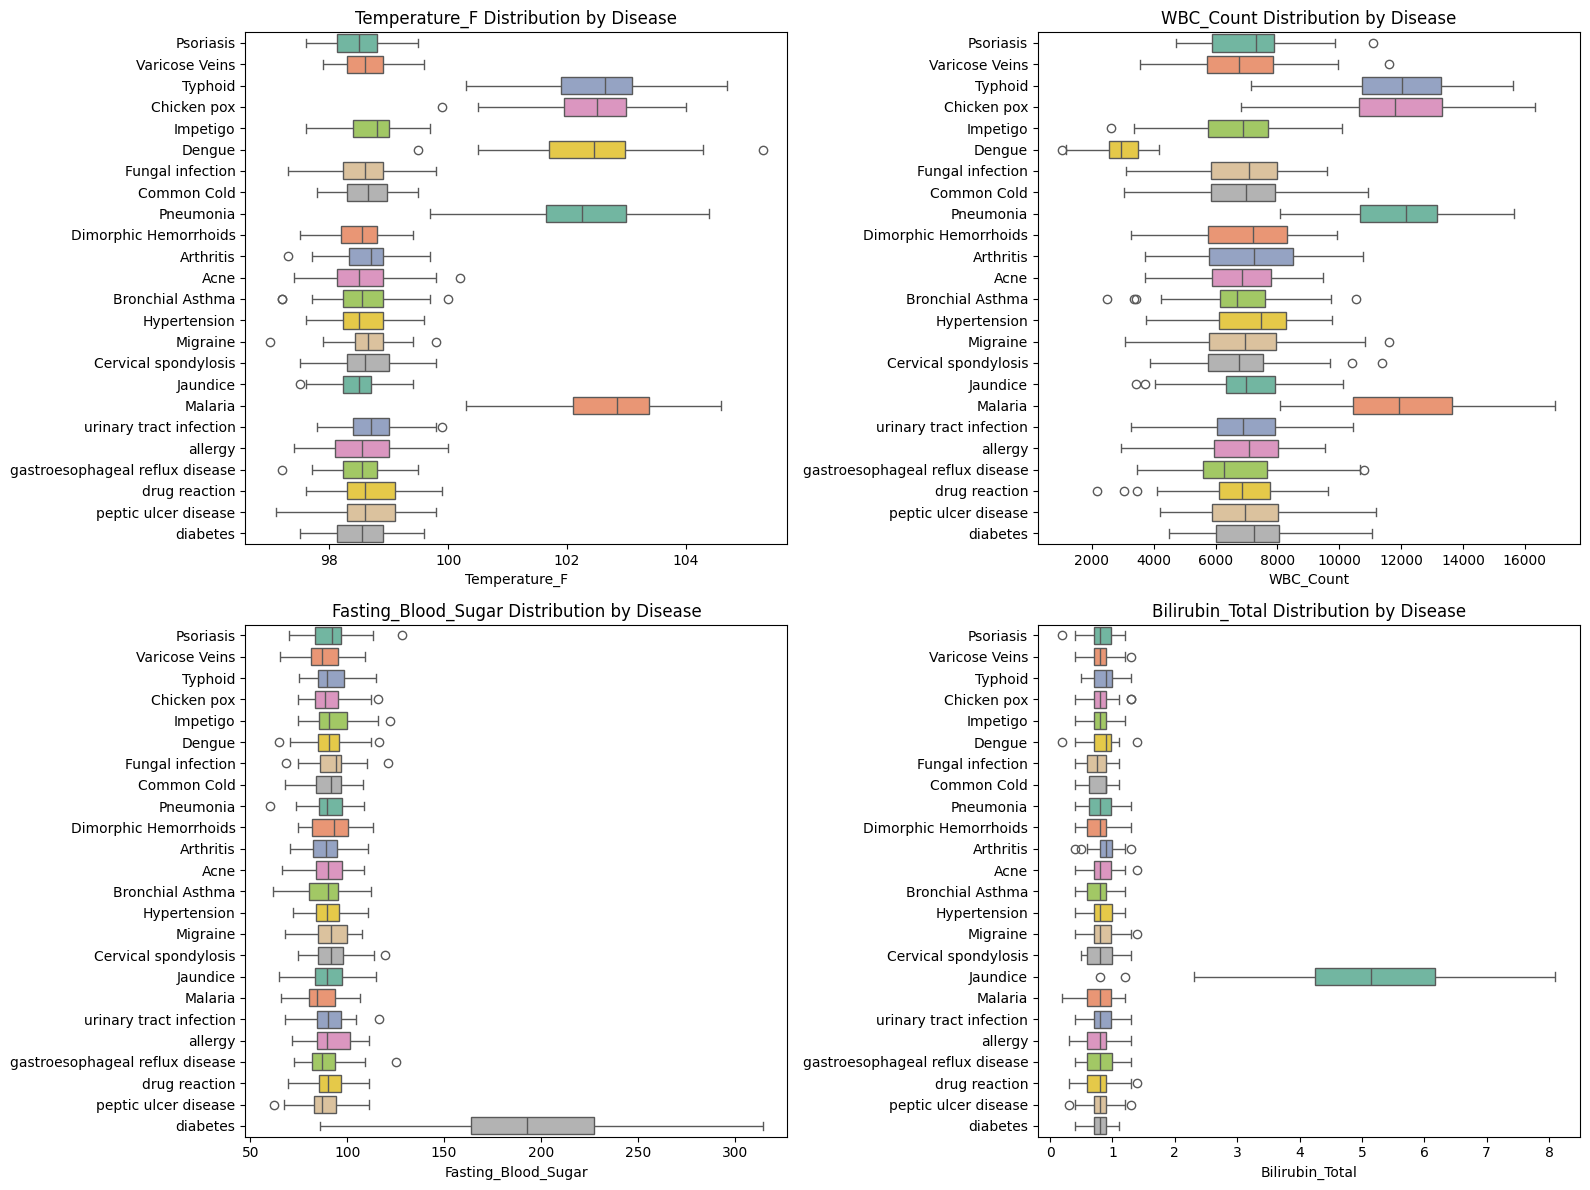

In [10]:
# Fig 4.8 Lab Value Distributions by Disease
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
features_to_plot = ['Temperature_F', 'WBC_Count', 'Fasting_Blood_Sugar', 'Bilirubin_Total']

for i, feature in enumerate(features_to_plot):
    ax = axes[i//2, i%2]
    sns.boxplot(data=df_augmented, x=feature, y='label', ax=ax, palette='Set2')
    ax.set_title(f'{feature} Distribution by Disease')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

### 4.3 Feature Correlation
Understanding the collinearity between clinical parameters and temporal features.

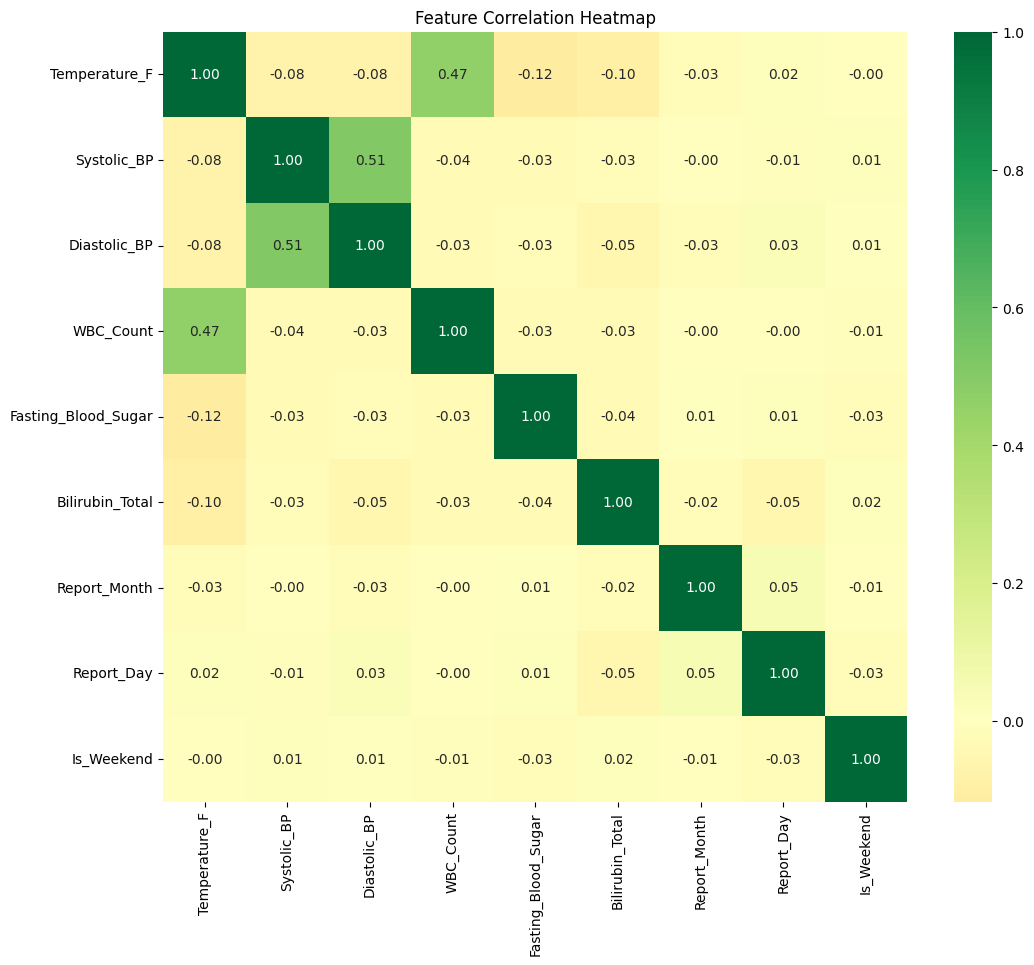

In [11]:
# Fig 4.9 Feature Correlation Analysis
plt.figure(figsize=(12, 10))
numeric_df = df_augmented.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

### 4.4 Temporal Trends
Visualizing seasonal patterns or monthly variation in reported cases.

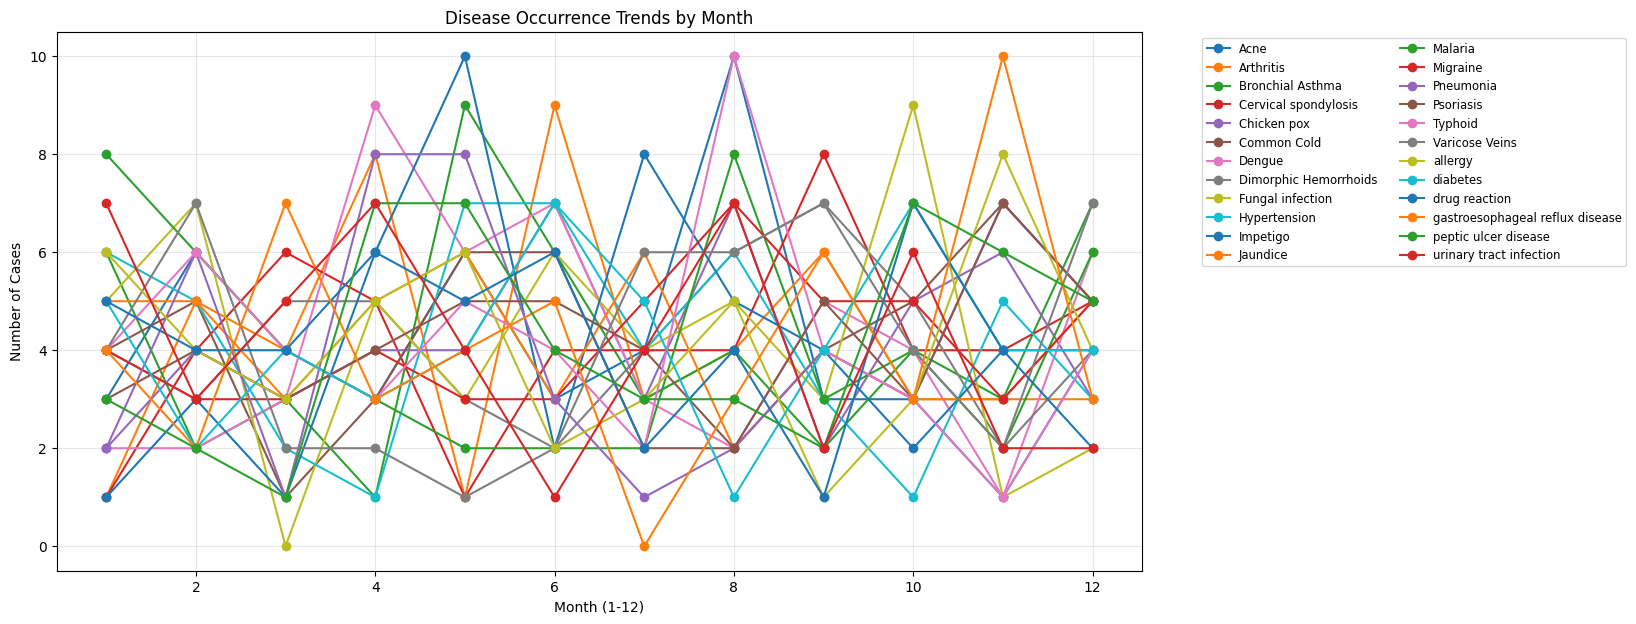

In [12]:
# Fig 4.10 Temporal Trends (Monthly Disease Occurrence)
plt.figure(figsize=(14, 7))
disease_monthly = df_augmented.groupby(['Report_Month', 'label']).size().unstack().fillna(0)
disease_monthly.plot(kind='line', marker='o', ax=plt.gca())
plt.title('Disease Occurrence Trends by Month')
plt.xlabel('Month (1-12)')
plt.ylabel('Number of Cases')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

### Fig 4.8 Preprocessing Workflow Visualization
The following diagram outlines the data flow from raw input to model training:

```mermaid
graph TD
    A[Raw Data: Symptom Descriptions] --> B[Synthetic Augmentation: Lab Tests]
    B --> C[Temporal Feature Engineering]
    C --> D[Data Validation & Cleaning]
    D --> E[Feature Encoding: TF-IDF & Scaling]
    E --> F[Multimodal Model: Random Forest]
    F --> G[Disease Prediction Output]
```

## 5. Data Preprocessing and Model Definition
We will combine the text column (`text`) with the numerical lab and temporal columns using `ColumnTransformer`.


In [16]:
# Features and Target
X = df_augmented.drop(columns=['label'])
y = df_augmented['label']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define columns
text_col = 'text'
num_cols = ['Temperature_F', 'Systolic_BP', 'Diastolic_BP', 'WBC_Count', 'Fasting_Blood_Sugar', 'Bilirubin_Total', 'Report_Month', 'Report_Day', 'Is_Weekend']

# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=2000), text_col),
        ('num', StandardScaler(), num_cols)
    ]
)

# Full Model Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])


## 6. Model Training and Evaluation


In [17]:
# Train Model
model.fit(X_train, y_train)

# Predict and Evaluate
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9833

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00         7
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        11
           Cervical spondylosis       1.00      1.00      1.00         7
                    Chicken pox       1.00      1.00      1.00        12
                    Common Cold       0.92      0.92      0.92        12
                         Dengue       1.00      1.00      1.00        12
          Dimorphic Hemorrhoids       1.00      1.00      1.00         7
               Fungal infection       1.00      1.00      1.00        13
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        11
                       Jaundice       1.00      1.00      1.00        11
                        Malaria 

### 6.1 Model Interpretation: Confusion Matrix
Visualizing where the model is accurate and where it might confuse similar conditions.

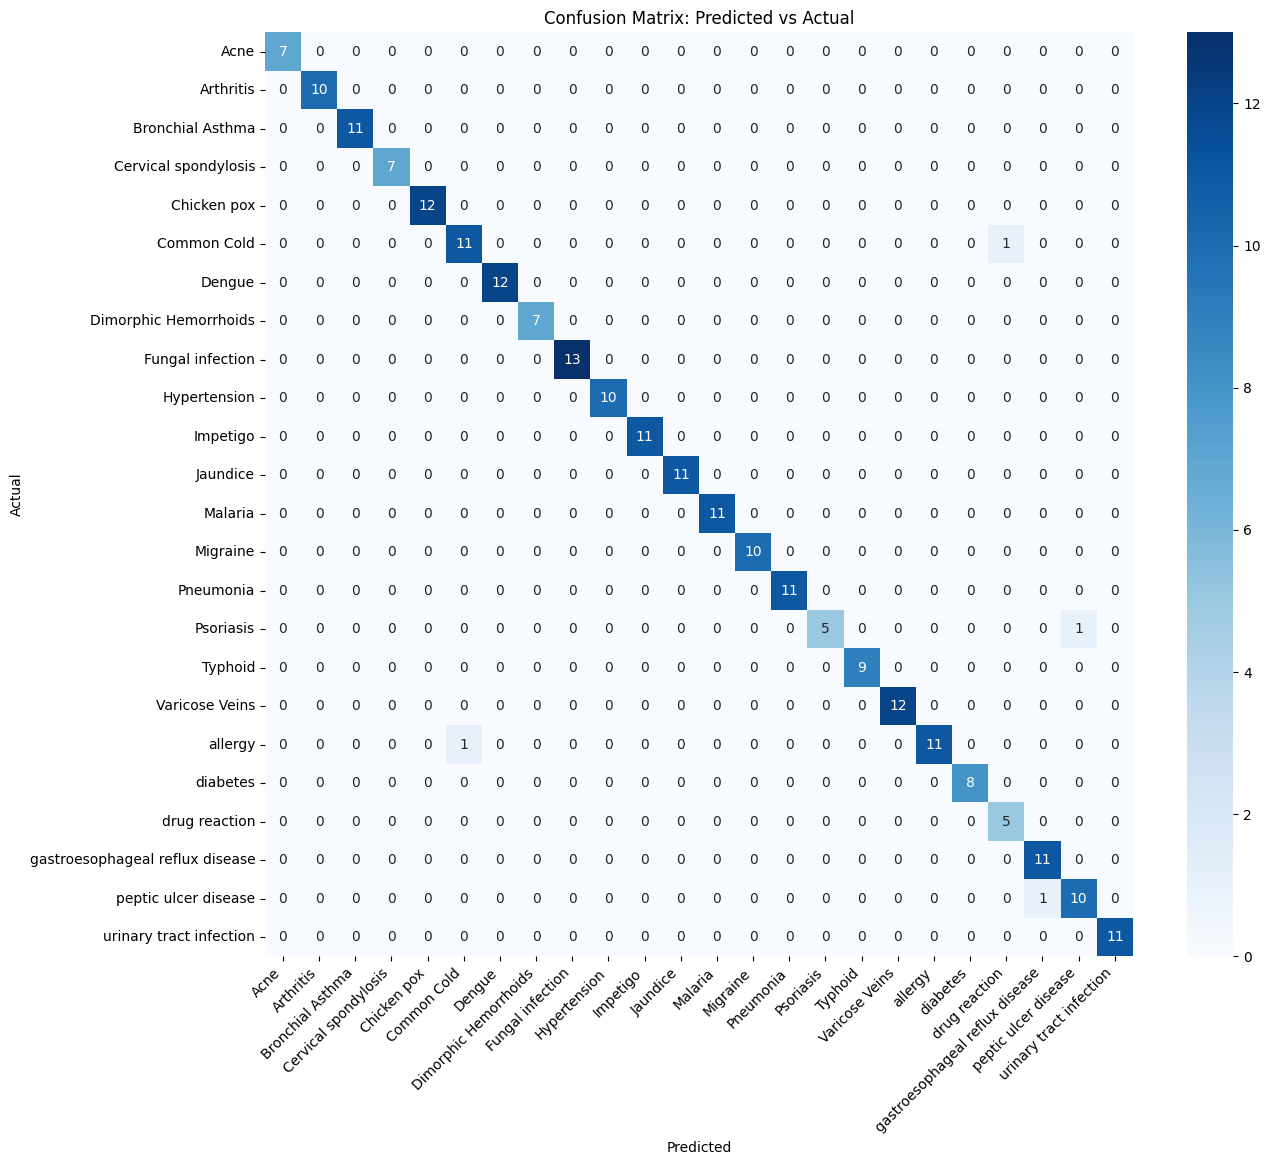

In [18]:
# Fig 6.1 Confusion Matrix
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(14, 12))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.show()

### 6.2 Feature Importance
Identifying which symptoms or lab values are most influential in the model's decision-making process.

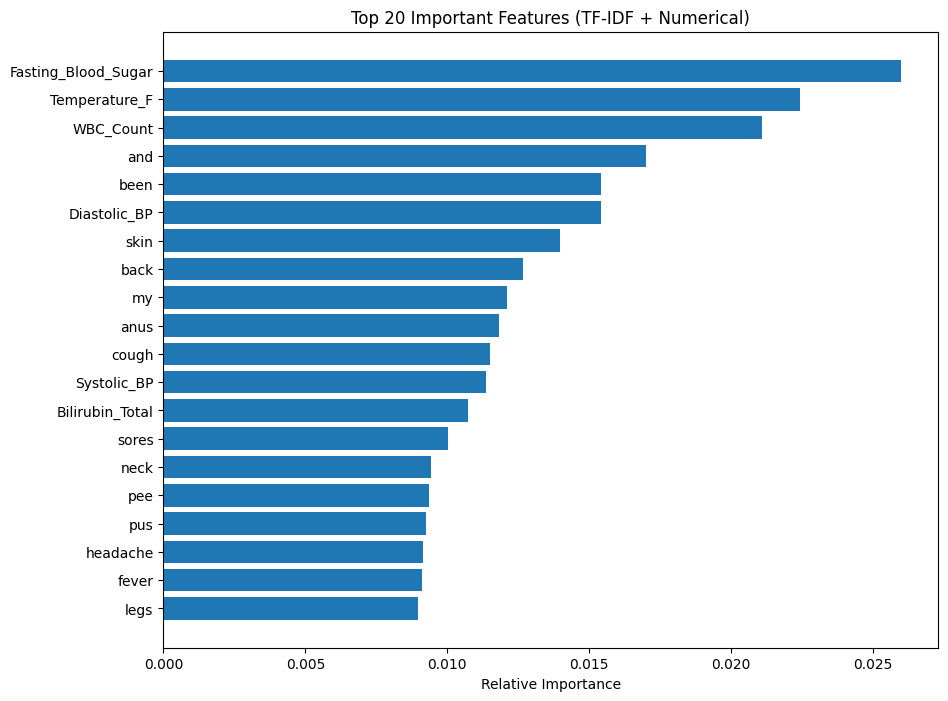

In [19]:
# Fig 6.2 Feature Importance
# Extract feature names from the pipeline
tfidf_features = model.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out()
all_features = list(tfidf_features) + num_cols
importances = model.named_steps['classifier'].feature_importances_

# Get top 20 features
indices = np.argsort(importances)[-20:]

plt.figure(figsize=(10, 8))
plt.title('Top 20 Important Features (TF-IDF + Numerical)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [all_features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## 7. Input System for Prediction
Below is a function to predict a disease from a new patient's symptom description and their laboratory test values. It demonstrates how user inputs can be passed to our trained model to peddle the most likely disease.


In [8]:
def predict_disease(symptoms_text, temp=98.6, sys_bp=120, dia_bp=80, wbc=7000, fbs=90.0, bilirubin=0.8):
    '''
    Given symptom description and optional lab test values, predict the disease.
    If lab values are not provided, it assumes normal healthy baseline values.
    '''
    # Create input dataframe
    input_data = pd.DataFrame([{
        'text': symptoms_text,
        'Temperature_F': temp,
        'Systolic_BP': sys_bp,
        'Diastolic_BP': dia_bp,
        'WBC_Count': wbc,
        'Fasting_Blood_Sugar': fbs,
        'Bilirubin_Total': bilirubin
    }])
    
    # Predict using trained pipeline
    prediction = model.predict(input_data)[0]
    probabilities = model.predict_proba(input_data)[0]
    
    # Get top 3 predictions
    top3_idx = np.argsort(probabilities)[-3:][::-1]
    classes = model.classes_
    
    print(f"--- Patient Prediction ---")
    print(f"Symptoms: {symptoms_text}")
    print(f"Labs: Temp: {temp}F, BP: {sys_bp}/{dia_bp}, WBC: {wbc}, FBS: {fbs}, Bilirubin: {bilirubin}")
    print(f"\nPrimary Diagnosis: **{prediction}**")
    print("\nTop 3 Possibilities:")
    for i in top3_idx:
        print(f" - {classes[i]}: {probabilities[i]*100:.2f}%")
    print("-" * 26)
    
    return prediction


In [9]:
# Example 1: High fever and low WBC (Dengue symptoms)
predict_disease(
    symptoms_text="I have severe joint and muscle pain, high fever, and some rash on my body. I feel extremely exhausted.",
    temp=103.5,
    sys_bp=110,
    dia_bp=75,
    wbc=2500, # Low WBC indicative of Dengue
    fbs=95,
    bilirubin=0.9
)


--- Patient Prediction ---
Symptoms: I have severe joint and muscle pain, high fever, and some rash on my body. I feel extremely exhausted.
Labs: Temp: 103.5F, BP: 110/75, WBC: 2500, FBS: 95, Bilirubin: 0.9

Primary Diagnosis: **Dengue**

Top 3 Possibilities:
 - Dengue: 41.00%
 - Chicken pox: 10.00%
 - Malaria: 9.00%
--------------------------


'Dengue'

In [10]:
# Example 2: Increased thirst and frequent urination (Diabetes)
predict_disease(
    symptoms_text="I have been feeling very thirsty lately and need to urinate frequently, especially at night. Also feeling tired.",
    temp=98.6,
    sys_bp=125,
    dia_bp=80,
    wbc=7200,
    fbs=220, # High fasting blood sugar
    bilirubin=0.8
)


--- Patient Prediction ---
Symptoms: I have been feeling very thirsty lately and need to urinate frequently, especially at night. Also feeling tired.
Labs: Temp: 98.6F, BP: 125/80, WBC: 7200, FBS: 220, Bilirubin: 0.8

Primary Diagnosis: **diabetes**

Top 3 Possibilities:
 - diabetes: 45.00%
 - urinary tract infection: 12.00%
 - Migraine: 12.00%
--------------------------


'diabetes'

In [15]:
# Example 3: Yellowish skin and eyes (Jaundice)
predict_disease(
    symptoms_text="My skin and eyes are looking slightly yellowish. I feel fatigued, have dark urine, and my stomach hurts a bit.",
    temp=99.0,
    sys_bp=115,
    dia_bp=75,
    wbc=7500,
    fbs=90,
    bilirubin=4.5 # High bilirubin
)


--- Patient Prediction ---
Symptoms: My skin and eyes are looking slightly yellowish. I feel fatigued, have dark urine, and my stomach hurts a bit.
Labs: Temp: 99.0F, BP: 115/75, WBC: 7500, FBS: 90, Bilirubin: 4.5

Primary Diagnosis: **Jaundice**

Top 3 Possibilities:
 - Jaundice: 34.00%
 - allergy: 15.00%
 - urinary tract infection: 10.00%
--------------------------


'Jaundice'

In [14]:
# Example 4: ONLY Symptoms are provided (No Lab Data)
predict_disease(
    symptoms_text="I have an itchy rash all over my arms and legs with red scaly patches."
)


--- Patient Prediction ---
Symptoms: I have an itchy rash all over my arms and legs with red scaly patches.
Labs: Temp: 98.6F, BP: 120/80, WBC: 7000, FBS: 90.0, Bilirubin: 0.8

Primary Diagnosis: **Varicose Veins**

Top 3 Possibilities:
 - Varicose Veins: 18.00%
 - drug reaction: 16.00%
 - Psoriasis: 13.00%
--------------------------


'Varicose Veins'

## 8. Interactive Widget (Optional)
If running inside a Jupyter Notebook or Colab, you can use `ipywidgets` to create an interactive form.


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

text_input = widgets.Textarea(description='Symptoms:', placeholder='Describe symptoms here...')
temp_input = widgets.FloatText(value=98.6, description='Temp (F):')
sys_input = widgets.IntText(value=120, description='Sys BP:')
dia_input = widgets.IntText(value=80, description='Dia BP:')
wbc_input = widgets.IntText(value=7000, description='WBC Count:')
fbs_input = widgets.FloatText(value=90.0, description='Fasting BS:')
bil_input = widgets.FloatText(value=0.8, description='Bilirubin:')

button = widgets.Button(description='Predict Disease', button_style='success')
output = widgets.Output()

def on_button_clicked(b):
    with output:
        clear_output()
        predict_disease(
            text_input.value, temp_input.value, sys_input.value, dia_input.value,
            wbc_input.value, fbs_input.value, bil_input.value
        )

button.on_click(on_button_clicked)

display(widgets.VBox([
    text_input, temp_input, sys_input, dia_input, wbc_input, fbs_input, bil_input, button, output
]))
